# 05 - Portfolio-construction extensions (post-hoc research)

Can portfolio engineering rescue the frozen 3-factor Ridge signal? This notebook tests whether
faster rebalancing, tail concentration and a turnover buffer improve the baseline. The baseline
earned a test-period net Sharpe of 0.06 at 6 bps per dollar traded.

**Isolation.** `run_pipeline.py`, `config.yaml` and everything in `results/` are left untouched.
The notebook rebuilds the exact frozen composite signal from the cached price snapshot and the
selections recorded in `results/tables`, then re-uses the baseline backtest engine (`src/backtest.py`).
The timing, cost model and universe are identical.

**Integrity caveats. Read these before the numbers.**
1. *The test period is no longer blind.* The baseline test results (2020–2025) were already
   observed, and these variants are motivated partly by them. Test numbers below are therefore
   **post-hoc**, not a clean out-of-sample confirmation. The variants are ranked on **validation**
   (2016–2019), and test results are reported only for transparency.
2. *The decay premise is checked, not assumed.* The baseline decay table (train + validation) shows
   reversal mean Rank IC of 0.012 / 0.016 / 0.015 / 0.014 at 1 / 5 / 10 / 20 days. That is a
   slow decay, not a collapse after 5–7 days. Faster rebalancing is still worth testing, but the
   decay evidence alone does not justify it.
3. *Variant A was partly tested before.* The frozen design grid already included a 5-day quintile
   rebalance of this beta-neutral signal: validation net Sharpe −0.43 vs −0.04 for 20 days
   (`results/tables/diagnostics/design_variant_selection.md`). It is re-run here as the
   reference point for variants B and C.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from src import plots  # shared palette and style
from src.backtest import rebalance_schedule, run_backtest
from src.extensions import frozen_choices, hysteresis_weights, quantile_weights, rebuild_baseline_inputs
from src.metrics import drawdown, market_beta, performance_summary
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 220)
%matplotlib inline
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

## 1. Rebuild the frozen baseline signal and verify that it reproduces the pipeline

In [2]:
inp = rebuild_baseline_inputs()
cfg, rets, spy, composite, periods = inp["cfg"], inp["returns"], inp["benchmark"], inp["composite"], inp["periods"]
lag = cfg["portfolio"]["execution_lag"]
cost_bps = cfg["costs"]["commission_bps"] + cfg["costs"]["spread_bps"]
slip_bps = cfg["costs"]["slippage_bps"]
end = pd.Timestamp(periods["test"][1])
start = pd.Timestamp(periods["train"][0])
print("frozen choices:", inp["choices"], "| ridge alpha:", inp["alpha"])
print(f"costs: {cost_bps} bps commission+spread + {slip_bps} bps slippage per dollar traded; execution lag {lag} day")

frozen choices: {'windows': {'reversal': 5, 'momentum': 120, 'volatility': 60}, 'beta_neutral': True, 'rebalance_every': 20} | ridge alpha: 1000.0
costs: 3.0 bps commission+spread + 3.0 bps slippage per dollar traded; execution lag 1 day


In [3]:
# Baseline exactly as frozen: 20-day rebalance, top/bottom 20%, equal weight
base_daily, _ = run_backtest(quantile_weights(composite, 0.2), rets, rebalance_schedule(rets.index, start, 20),
                             lag, cost_bps, slip_bps, end=end)
saved = pd.read_parquet(ROOT / "data/processed/backtest_ensemble.parquet")
diff = (base_daily["net_return"] - saved["net_return"].reindex(base_daily.index)).abs().max()
print("max |daily net return difference| vs saved baseline backtest:", diff)
assert diff < 1e-12, "rebuilt baseline does not match the frozen pipeline"

max |daily net return difference| vs saved baseline backtest: 0.0


## 2. Variants

All variants use the identical composite signal, universe, execution lag (signal at close t, trade
at close t+1) and cost model (6 bps per dollar traded). Every book is dollar neutral (+0.5 long /
−0.5 short at each rebalance) and equal-weighted within each leg.

| Variant | Rebalance | Book | Buffer |
|---|---|---|---|
| Baseline | 20 days | top/bottom 20% | none |
| A | 5 days | top/bottom 20% | none |
| B | 5 days | top/bottom 10% | none |
| B5 | 5 days | top/bottom 5% (requested ventile comparison) | none |
| C | 5 days | enter top/bottom 10% | stay until outside top/bottom 20% |

The buffer uses percentile bands rather than fixed counts (e.g. "top 30 / exit beyond 50"). The
universe grows from about 280 to about 490 names over 2007–2025, so a fixed count would mean a
different concentration in each period. With about 450 names, 10% / 20% is roughly top 45 / exit
beyond 90.

In [4]:
def sched(k):
    return rebalance_schedule(rets.index, start, k)

variants = {
    "Baseline": (quantile_weights(composite, 0.20), sched(20)),
    "A": (quantile_weights(composite, 0.20), sched(5)),
    "B": (quantile_weights(composite, 0.10), sched(5)),
    "B5": (quantile_weights(composite, 0.05), sched(5)),
    "C": (hysteresis_weights(composite, sched(5), entry_q=0.10, exit_q=0.20), sched(5)),
}
daily = {k: run_backtest(w, rets, s, lag, cost_bps, slip_bps, end=end)[0] for k, (w, s) in variants.items()}
assert all(d["net_exposure"].abs().max() < 0.25 for d in daily.values())
{k: round(d["n_positions"].loc[periods["test"][0]:].mean(), 1) for k, d in daily.items()}

{'Baseline': np.float64(185.8),
 'A': np.float64(186.0),
 'B': np.float64(93.1),
 'B5': np.float64(46.5),
 'C': np.float64(112.2)}

## 3. Comparative performance (gross and net of 6 bps per dollar traded)

In [5]:
def summarize(d, s, e):
    x = d.loc[s:e]
    p = performance_summary(x, {}, spy)
    return {
        "Gross Return %": x["gross_return"].mean() * 252 * 100,
        "Net Return %": p["ann_return"] * 100,
        "Volatility %": p["ann_volatility"] * 100,
        "Gross Sharpe": p["sharpe_gross"],
        "Net Sharpe": p["sharpe"],
        "Turnover x/yr": p["ann_turnover"],
        "Cost Drag %": p["ann_cost_drag"] * 100,
        "Max DD %": p["max_drawdown"] * 100,
        "Beta (SPY)": p["market_beta"],
        "Beta t": p["market_beta_t"],
        "Avg Positions": x["n_positions"].mean(),
    }

comp = pd.concat({pn: pd.DataFrame({k: summarize(d, *se) for k, d in daily.items()}).T
                  for pn, se in periods.items()}, names=["period", "variant"])
comp

Gross Return %  Net Return %  Volatility %  Gross Sharpe  Net Sharpe  Turnover x/yr  Cost Drag %  Max DD %  Beta (SPY)  Beta t  Avg Positions
period     variant                                                                                                                                                
train      Baseline          -0.441        -1.220         6.087        -0.073      -0.200         12.980        0.779   -34.798      -0.077  -5.955        129.325
           A                  0.108        -2.529         6.099         0.018      -0.415         43.944        2.637   -38.876      -0.086  -7.515        130.212
           B                  0.862        -2.257         8.996         0.096      -0.251         51.981        3.119   -45.977      -0.117  -6.293         65.119
           B5                -0.800        -4.244        11.719        -0.068      -0.362         57.404        3.444   -58.320      -0.126  -5.272         32.603
           C                  0.231        -1.810         7.836         0.029      -0.231         34.008        2.040   -42.624      -0.104  -6.555         83.916
validation Baseline           0.528        -0.193         4.949         0.107      -0.039         12.013        0.721    -8.368      -0.007  -0.512        161.006
           A                  0.292        -2.183         5.031         0.058      -0.434         41.250        2.475   -11.245      -0.018  -1.343        161.230
           B                  0.512        -2.429         6.661         0.077      -0.365         49.010        2.941   -17.217      -0.025  -1.464         80.568
           B5                 1.545        -1.763         8.572         0.180      -0.206         55.140        3.308   -19.929      -0.030  -1.281         40.261
           C                  1.242        -0.609         6.163         0.202      -0.099         30.838        1.850   -12.830      -0.024  -1.420        104.514
test       Baseline           1.388         0.399         6.280         0.221       0.064         16.483        0.989   -14.685       0.006   0.496        185.830
           A                  1.073        -2.615         6.565         0.164      -0.398         61.465        3.688   -24.680       0.012   0.849        185.962
           B                  2.092        -2.214         8.865         0.236      -0.250         71.778        4.307   -28.347       0.011   0.579         93.067
           B5                 1.252        -3.457        11.542         0.109      -0.300         78.490        4.709   -38.591       0.006   0.295         46.494
           C                  1.366        -1.955         8.426         0.162      -0.232         55.353        3.321   -26.014       0.008   0.430        112.178

### Validation (selection period) and test (post-hoc) side by side

In [6]:
cols = ["Gross Sharpe", "Net Sharpe", "Net Return %", "Turnover x/yr", "Max DD %", "Beta (SPY)"]
side = comp[cols].unstack("period").swaplevel(axis=1).sort_index(axis=1, level=0)
side = side[["train", "validation", "test"]]
side

period        train                                                             validation                                                                   test                                                \
         Beta (SPY) Gross Sharpe Max DD % Net Return % Net Sharpe Turnover x/yr Beta (SPY) Gross Sharpe Max DD % Net Return % Net Sharpe Turnover x/yr Beta (SPY) Gross Sharpe Max DD % Net Return % Net Sharpe   
variant                                                                                                                                                                                                           
Baseline     -0.077       -0.073  -34.798       -1.220     -0.200        12.980     -0.007        0.107   -8.368       -0.193     -0.039        12.013      0.006        0.221  -14.685        0.399      0.064   
A            -0.086        0.018  -38.876       -2.529     -0.415        43.944     -0.018        0.058  -11.245       -2.183     -0.434        41.250      0.012        0.164  -24.680       -2.615     -0.398   
B            -0.117        0.096  -45.977       -2.257     -0.251        51.981     -0.025        0.077  -17.217       -2.429     -0.365        49.010      0.011        0.236  -28.347       -2.214     -0.250   
B5           -0.126       -0.068  -58.320       -4.244     -0.362        57.404     -0.030        0.180  -19.929       -1.763     -0.206        55.140      0.006        0.109  -38.591       -3.457     -0.300   
C            -0.104        0.029  -42.624       -1.810     -0.231        34.008     -0.024        0.202  -12.830       -0.609     -0.099        30.838      0.008        0.162  -26.014       -1.955     -0.232   

period                  
         Turnover x/yr  
variant                 
Baseline        16.483  
A               61.465  
B               71.778  
B5              78.490  
C               55.353

In [7]:
best_val = comp.loc["validation", "Net Sharpe"].idxmax()
print("Best variant by VALIDATION net Sharpe:", best_val,
      f"({comp.loc[('validation', best_val), 'Net Sharpe']:.2f}); its post-hoc test net Sharpe:",
      f"{comp.loc[('test', best_val), 'Net Sharpe']:.2f}")

Best variant by VALIDATION net Sharpe: Baseline (-0.04); its post-hoc test net Sharpe: 0.06


### Turnover reduction from the buffer (C vs B, both 5-day / 10% entry)

In [8]:
to = comp["Turnover x/yr"].unstack("variant")
red = pd.DataFrame({
    "B turnover": to["B"], "C turnover": to["C"],
    "reduction %": (1 - to["C"] / to["B"]) * 100,
    "B net Sharpe": comp["Net Sharpe"].unstack("variant")["B"],
    "C net Sharpe": comp["Net Sharpe"].unstack("variant")["C"],
    "B gross Sharpe": comp["Gross Sharpe"].unstack("variant")["B"],
    "C gross Sharpe": comp["Gross Sharpe"].unstack("variant")["C"],
}).loc[["train", "validation", "test"]]
red

,B turnover,C turnover,reduction %,B net Sharpe,C net Sharpe,B gross Sharpe,C gross Sharpe
period,,,,,,,
train,51.981,34.008,34.576,-0.251,-0.231,0.096,0.029
validation,49.010,30.838,37.077,-0.365,-0.099,0.077,0.202
test,71.778,55.353,22.883,-0.250,-0.232,0.236,0.162


### Break-even cost: net Sharpe as a function of total cost per dollar traded

In [9]:
def sharpe_at(d, bps):
    r = d["gross_return"] - d["turnover"] * bps * 1e-4
    return r.mean() / r.std() * np.sqrt(252)

grid = [0, 2, 4, 6, 8, 10, 15, 20]
be = pd.concat({pn: pd.DataFrame({k: [sharpe_at(d.loc[slice(*se)], b) for b in grid] for k, d in daily.items()},
                                 index=pd.Index(grid, name="total_bps")) for pn, se in periods.items()
                if pn in ("validation", "test")}, axis=1)
be

validation                                 test                            
            Baseline      A      B     B5      C Baseline      A      B     B5      C
total_bps                                                                            
0              0.107  0.058  0.077  0.180  0.202    0.221  0.164  0.236  0.109  0.162
2              0.058 -0.106 -0.070  0.052  0.101    0.169 -0.024  0.074 -0.028  0.031
4              0.010 -0.270 -0.218 -0.077  0.001    0.116 -0.211 -0.088 -0.164 -0.101
6             -0.039 -0.434 -0.365 -0.206 -0.099    0.064 -0.398 -0.250 -0.300 -0.232
8             -0.087 -0.597 -0.511 -0.334 -0.199    0.011 -0.585 -0.411 -0.435 -0.363
10            -0.136 -0.760 -0.657 -0.462 -0.299   -0.041 -0.770 -0.572 -0.570 -0.494
15            -0.256 -1.162 -1.019 -0.780 -0.547   -0.172 -1.227 -0.969 -0.905 -0.818
20            -0.375 -1.556 -1.373 -1.094 -0.794   -0.301 -1.671 -1.357 -1.235 -1.137

## 4. Figures

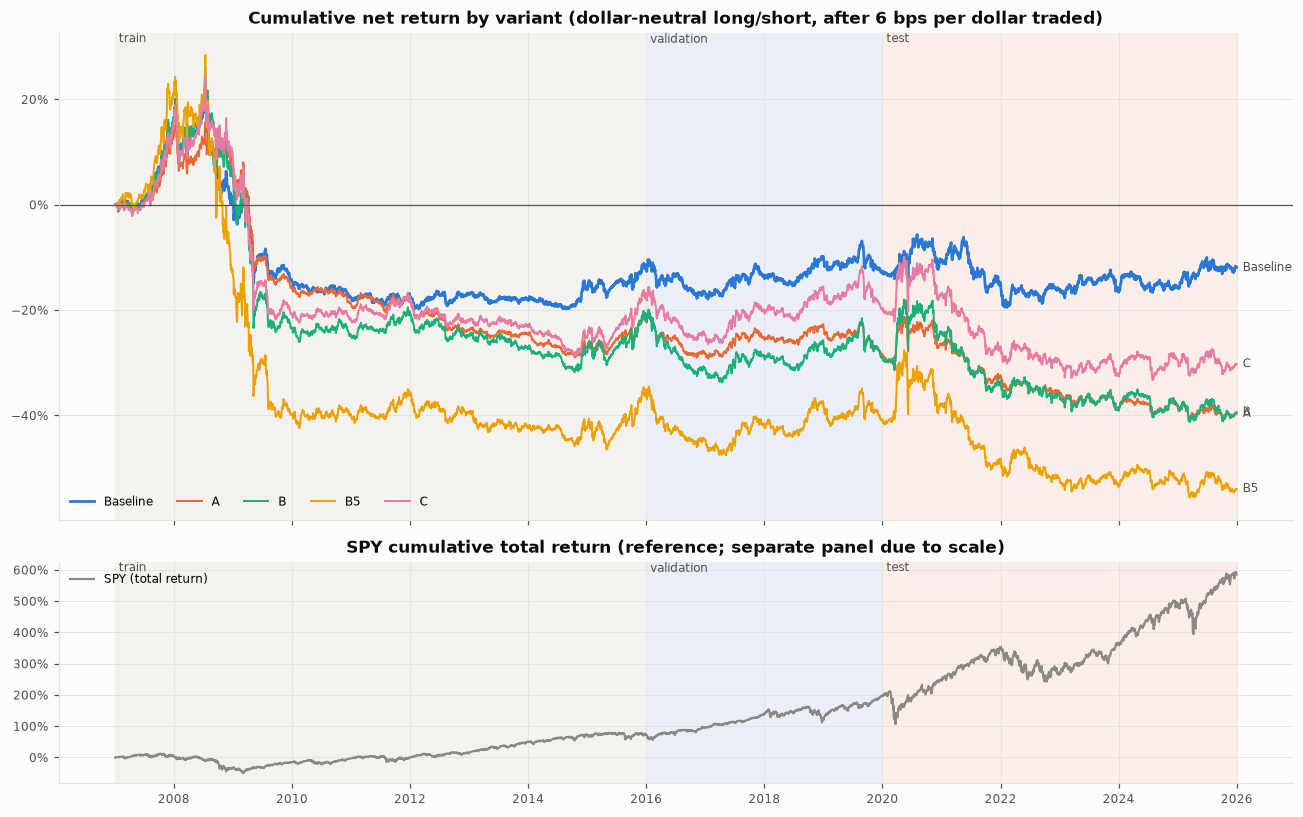

In [10]:
VCOL = {"Baseline": plots.COLORS["ensemble"], "A": plots.COLORS["equal_weight"], "B": plots.COLORS["reversal"],
        "B5": plots.COLORS["momentum"], "C": plots.COLORS["volatility"]}
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
ax = axes[0]
plots._shade_periods(ax, periods)
for k, d in daily.items():
    c = (1 + d["net_return"]).cumprod() - 1
    ax.plot(c.index, c, color=VCOL[k], lw=1.8 if k == "Baseline" else 1.3, label=k)
    ax.annotate(k, (c.index[-1], c.iloc[-1]), xytext=(4, 0), textcoords="offset points", fontsize=8, color=plots.INK_2, va="center")
ax.axhline(0, color=plots.INK_2, lw=0.8)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Cumulative net return by variant (dollar-neutral long/short, after 6 bps per dollar traded)")
ax.legend(loc="lower left", ncol=5)
# SPY on its own panel: a long-only index on the same axis would flatten every long/short line
ax = axes[1]
plots._shade_periods(ax, periods)
spy_c = (1 + spy.loc[start:end].fillna(0)).cumprod() - 1
ax.plot(spy_c.index, spy_c, color=plots.NEUTRAL, lw=1.4, label="SPY (total return)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("SPY cumulative total return (reference; separate panel due to scale)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

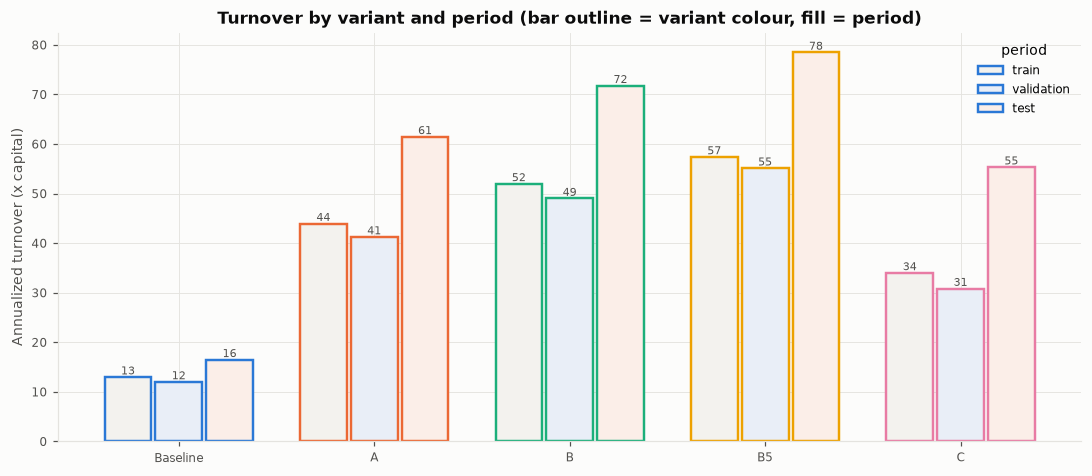

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.4))
pn_list = ["train", "validation", "test"]
x = np.arange(len(daily))
w = 0.26
for i, pn in enumerate(pn_list):
    vals = comp.loc[pn, "Turnover x/yr"].reindex(list(daily)).to_numpy()
    bars = ax.bar(x + (i - 1) * w, vals, w * 0.92, color=[plots.PERIOD_SHADE[pn]] * len(vals),
                  edgecolor=[VCOL[k] for k in daily], linewidth=1.6, label=pn)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=7, color=plots.INK_2)
ax.set_xticks(x, list(daily))
ax.set_ylabel("Annualized turnover (x capital)")
ax.set_title("Turnover by variant and period (bar outline = variant colour, fill = period)")
ax.legend(title="period")
plt.tight_layout(); plt.show()

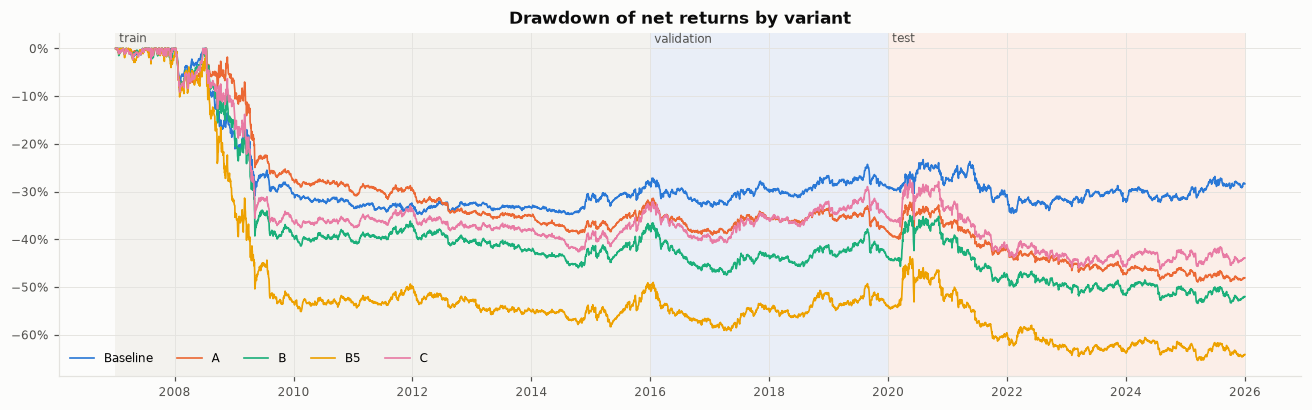

In [12]:
fig, ax = plt.subplots(figsize=(12, 3.8))
plots._shade_periods(ax, periods)
for k, d in daily.items():
    ax.plot(d.index, drawdown(d["net_return"]), color=VCOL[k], lw=1.1, label=k)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdown of net returns by variant")
ax.legend(loc="lower left", ncol=5)
plt.tight_layout(); plt.show()

## 5. Discussion and research summary

### Did buffering and tail concentration salvage the 5-day reversal alpha?

*Source: `notebooks/05_portfolio_optimization_extensions.ipynb`. It uses the same frozen signal, universe, lag and 6 bps cost model as the baseline, which it reproduces exactly. Variants are ranked on validation; test columns are descriptive only, because the test period had already been observed. Question: did buffering and tail concentration salvage the 5-day reversal alpha?*

**No.** At 6 bps per dollar traded, none of the four variants beats the frozen baseline (20-day
rebalance, quintiles). This holds on validation, where variants are ranked, and in the post-hoc
test period. Every variant has a negative net Sharpe in every period.

| Net Sharpe | Baseline | A (5d, 20%) | B (5d, 10%) | B5 (5d, 5%) | C (5d, 10%→20% buffer) |
|---|---:|---:|---:|---:|---:|
| Validation (selection) | **−0.04** | −0.43 | −0.37 | −0.21 | −0.10 |
| Test (post-hoc) | **0.06** | −0.40 | −0.25 | −0.30 | −0.23 |

**1. Horizon-aligned rebalancing (A) adds cost, not alpha.** Rebalancing every 5 days instead of 20
does not raise the *gross* Sharpe. It falls from 0.11 to 0.06 on validation and from 0.22 to 0.16
on test. Turnover meanwhile rises about 3.5×, from 12–16× to 41–61× capital per year, and the cost
drag goes from about 0.7–1.0% to 2.5–3.7% a year. This matches the decay table: reversal IC is
almost flat from 5 to 20 days, so the 20-day book is not holding "stale" positions. The premise
that the edge decays within 5–7 days is not supported by this data.

**2. Tail concentration (B, B5) does not widen the spread enough.** Concentrating into the top and
bottom 10% or 5% raises gross Sharpe only a little and not consistently. B5 reaches 0.18 gross on
validation, but B is 0.08. On test, B is 0.24 and B5 is 0.11. Volatility rises from about 5–6% to
7–12%, maximum drawdown roughly doubles, and turnover rises further (49–78× a year), because extreme
ranks churn faster. The composite's predictive power (IC about 0.01) is spread thinly across the
cross-section. It is not concentrated in the tails, so fewer names add noise without adding spread.

**3. The turnover buffer (C) works mechanically but is not enough.** The 10% entry / 20% exit band
cuts turnover versus B by 35% (train), 37% (validation) and 23% (test). It also gives the best
validation gross Sharpe (0.20), and net Sharpe improves from −0.37 to −0.10 on validation. Even so,
C still trades 2.5–3.5× as much as the baseline. Its break-even cost is about 4 bps per dollar
traded on validation and about 2.5 bps on test, against the 6 bps assumed. On test, the buffer
barely helps (−0.25 to −0.23).

**Break-even view.** At zero cost, C (0.20) and B5 (0.18) beat the baseline (0.11) on validation.
The ranking reverses at about 3–4 bps. The baseline is the only construction that is roughly
cost-neutral at realistic large-cap friction, and only barely: it breaks even at about 4 bps on
validation and about 8.5 bps on test.

**Beta and neutrality.** Every variant stays dollar neutral at each rebalance, and the measured beta
to SPY is close to zero in validation and test (|beta| ≤ 0.03). Concentrated books carry slightly
more negative beta in train (down to −0.13). None of the differences above comes from market
exposure.

**Conclusion.** The bottleneck is not portfolio construction. The signal's predictive strength
(rank IC about 0.01 on the composite) is too small relative to the friction of trading S&P 500
names at the frequency needed to harvest it. Faster rebalancing and concentration both raise
trading volume faster than they raise the return spread, and buffering only partly offsets that.
The frozen baseline remains the best design among those tested. A genuine improvement would have
to come from a stronger signal, for example new information sources or intraday execution, or from
cheaper execution. It will not come from re-engineering the book around the same IC.

*Caveat:* the test period had already been observed before these variants were defined. The test
columns are therefore descriptive, not confirmatory. Selection and conclusions rest on validation.